In [2]:
import os
import sys
sys.path.insert(0, '../..')
import numpy as np
import matplotlib.pyplot as plt
import mssfp
import deepssfp
import deepssfp.analysis
import deepssfp.dataloader

In [3]:
path = 'D:/MRI/2024_Krithika_KneeStudy'
filters = ['HV1_lk_r1', 'HV2_lk_r1', 'HV3_lk_r1', 'HV4_lk_r1', 'HV5_lk_r1']
M = deepssfp.dataloader.read_complex_dicom_datasets(path, filters = filters)
print(M.shape)

new_shape = (M.shape[0] * M.shape[1],) + M.shape[2:]
M = M.reshape(new_shape)
print(M.shape)

memory_size = M.nbytes
print(f"Memory size: {memory_size / 1000000000} GB")

from skimage.filters import threshold_li
def create_segmentation_mask(M):
    # Create mask of phantom
    _ = np.sqrt(np.sum(np.abs(M)**2, axis=3))
    _ = abs(_)
    thresh = threshold_li(_)
    mask = np.abs(_) > thresh
    seg = mask * 1
    return seg

seg = create_segmentation_mask(M)
print(f"Segmentation shape: {seg.shape}")
print(f"Segmentation values: {np.unique(seg)}")

dataset = { 'M': M, 'seg': seg }

100%|██████████| 4/4 [00:07<00:00,  1.89s/it]


(5, 80, 416, 416, 4)
(400, 416, 416, 4)
Memory size: 2.2151168 GB
Segmentation shape: (400, 416, 416)
Segmentation values: [0 1]


In [4]:
modes=['BandRemoval:4', 'BandRemoval:2', 'SuperFOV', 'SyntheticBanding']
model_dir = "D:/DeepSSFP/"
model_name="knee_study"


===== Running experiment: SyntheticBanding =====
Model path: D:/DeepSSFP/knee_study_syntheticbanding
Dataset path: D:/DeepSSFP/knee_study_dataset.npy
Data shape: (400, 416, 416, 4)
Using same scaler for SyntheticBanding mode
Training data shape: (320, 416, 416, 4), (320, 416, 416, 4)
Input scaler stats: mean=0.1445, std=25.5165
Output scaler stats: mean=0.1445, std=25.5165
Selected indices: [65 12  6]
Figure size: (8, 6)


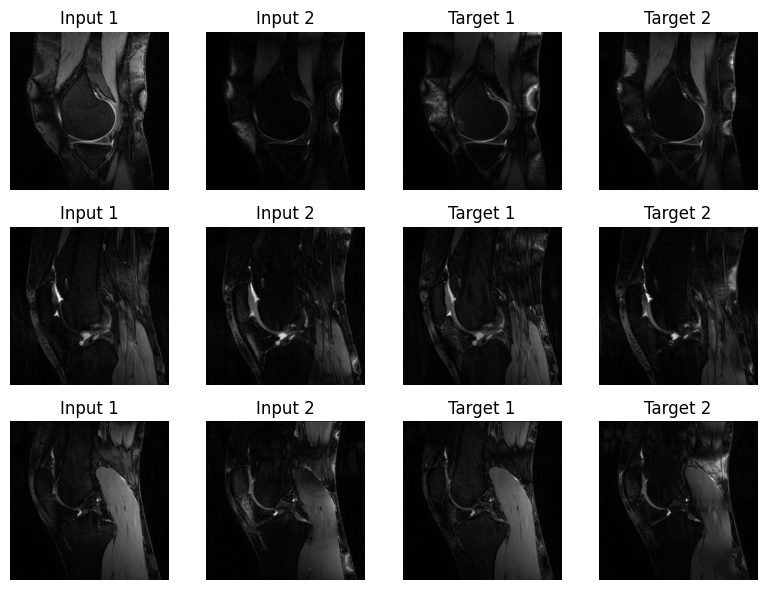

2025-04-03 23:36:24,833 - DeepSSFP - INFO - Model will be saved to: D:/DeepSSFP/knee_study_syntheticbanding
2025-04-03 23:36:24,834 - DeepSSFP - INFO - Training DataSet: (320, 416, 416, 4) | (320, 416, 416, 4)
2025-04-03 23:36:24,835 - DeepSSFP - INFO - Test DataSet: (80, 416, 416, 4) | (80, 416, 416, 4)



Training model...


2025-04-03 23:36:25,793 - DeepSSFP - INFO - Creating new model with dimensions: 416x416x4→4
2025-04-03 23:36:26,172 - DeepSSFP - INFO - Model created: unet


Model: "unet"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 img (InputLayer)            [(None, 416, 416, 4)]        0         []                            
                                                                                                  
 conv2d (Conv2D)             (None, 416, 416, 32)         1184      ['img[0][0]']                 
                                                                                                  
 conv2d_1 (Conv2D)           (None, 416, 416, 32)         9248      ['conv2d[0][0]']              
                                                                                                  
 batch_normalization (Batch  (None, 416, 416, 32)         128       ['conv2d_1[0][0]']            
 Normalization)                                                                                

In [ ]:
results = deepssfp.analysis.run_experiment(
    mode=deepssfp.DataMode.SyntheticBanding.value, 
    model_name=model_name,
    model_dir=model_dir,
    train_model=True,
    custom_dataset=dataset
)